In [3]:
API_KEY = '65a43e2388ed3c2ce80adc725feab885'

In [7]:
from fredapi import Fred
import pandas as pd

fred = Fred(api_key=API_KEY)

# Download each series
cpi        = fred.get_series('CPIAUCSL',   observation_start='2000-01-01')
unrate     = fred.get_series('UNRATE',     observation_start='2000-01-01')
fedfunds   = fred.get_series('FEDFUNDS',   observation_start='2000-01-01')
yield_spread = fred.get_series('T10Y2Y',   observation_start='2000-01-01')
m2         = fred.get_series('M2SL',       observation_start='2000-01-01')
oil        = fred.get_series('DCOILWTICO', observation_start='2000-01-01')
sentiment  = fred.get_series('UMCSENT',    observation_start='2000-01-01')

# Convert CPI to Year-over-Year inflation %
cpi = cpi.ffill()
inflation = cpi.pct_change(12) * 100

# Merge everything into one dataframe
df = pd.DataFrame({
    'inflation': inflation,
    'unemployment': unrate,
    'fed_funds': fedfunds,
    'yield_spread': yield_spread,
    'm2': m2.pct_change(12) * 100,  # M2 growth rate
    'oil': oil,
    'sentiment': sentiment
})

# Resample to monthly, forward fill small gaps
df = df.resample('MS').mean()
df = df.ffill()
df = df.dropna()

print(df.shape)
print(df.tail())

(307, 7)
            inflation  unemployment  fed_funds  yield_spread        m2  \
2026-03-01   3.285958           4.3       3.64      0.531364  4.575543   
2026-04-01   3.779246           4.3       3.64      0.520000  4.724051   
2026-05-01   4.166615           4.3       3.63      0.489000  5.580313   
2026-06-01   4.166615           4.2       3.63      0.357619  5.580313   
2026-07-01   4.166615           4.2       3.63      0.330000  5.580313   

                   oil  sentiment  
2026-03-01   91.383636       53.3  
2026-04-01  100.316667       49.8  
2026-05-01  102.134000       44.8  
2026-06-01   85.519500       44.8  
2026-07-01   85.519500       44.8  


In [5]:
# Lag features — past values of each variable
for col in ['inflation', 'unemployment', 'fed_funds', 'oil']:
    df[f'{col}_lag1'] = df[col].shift(1)
    df[f'{col}_lag3'] = df[col].shift(3)
    df[f'{col}_lag6'] = df[col].shift(6)

# Rolling averages — trend over past 3 and 6 months
df['inflation_roll3']    = df['inflation'].shift(1).rolling(3).mean()
df['inflation_roll6']    = df['inflation'].shift(1).rolling(6).mean()
df['unemployment_roll3'] = df['unemployment'].shift(1).rolling(3).mean()
df['oil_roll3']          = df['oil'].shift(1).rolling(3).mean()

# Theory-driven features
df['phillips_gap'] = df['unemployment'] - 4.5   # deviation from natural rate
df['real_rate']    = df['fed_funds'] - df['inflation']  # Taylor Rule signal

# Drop rows with NaN created by lagging
df = df.dropna()

print(f"Final dataset: {df.shape[0]} rows, {df.shape[1]} columns")

Final dataset: 301 rows, 25 columns


In [6]:
# Define features and target
target   = 'inflation'
features = [col for col in df.columns if col != target]

X = df[features]
y = df[target]

# Split by time — NOT random shuffle
train_end  = '2021-12-01'
val_end    = '2022-12-01'

X_train = X[X.index <= train_end]
y_train = y[y.index <= train_end]

X_val   = X[(X.index > train_end) & (X.index <= val_end)]
y_val   = y[(y.index > train_end) & (y.index <= val_end)]

X_test  = X[X.index > val_end]
y_test  = y[y.index > val_end]

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

Train: 246 | Val: 12 | Test: 43


In [8]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Naive prediction — just shift by 1
naive_pred = y_test.shift(1).dropna()
naive_actual = y_test[naive_pred.index]

naive_rmse = np.sqrt(mean_squared_error(naive_actual, naive_pred))
naive_mae  = mean_absolute_error(naive_actual, naive_pred)

print(f"Naive Baseline RMSE: {naive_rmse:.4f}")
print(f"Naive Baseline MAE:  {naive_mae:.4f}")

Naive Baseline RMSE: 0.3659
Naive Baseline MAE:  0.2563


In [10]:
import statsmodels.api as sm

# Select theory-driven features only
ols_features = [
    'inflation_lag1', 
    'unemployment_lag1', 
    'phillips_gap',
    'oil_lag1', 
    'fed_funds_lag1', 
    'real_rate'
]

X_train_ols = sm.add_constant(X_train[ols_features])
X_test_ols  = sm.add_constant(X_test[ols_features])

# Fit OLS model
ols_model = sm.OLS(y_train, X_train_ols).fit()

# Print summary — shows coefficients, p-values
print(ols_model.summary())

# Predict on test set
ols_pred = ols_model.predict(X_test_ols)

ols_rmse = np.sqrt(mean_squared_error(y_test, ols_pred))
ols_mae  = mean_absolute_error(y_test, ols_pred)

print(f"\nPhillips Curve OLS RMSE: {ols_rmse:.4f}")
print(f"Phillips Curve OLS MAE:  {ols_mae:.4f}")

                            OLS Regression Results                            
Dep. Variable:              inflation   R-squared:                       0.988
Model:                            OLS   Adj. R-squared:                  0.988
Method:                 Least Squares   F-statistic:                     3302.
Date:                Mon, 06 Jul 2026   Prob (F-statistic):          9.37e-227
Time:                        02:38:33   Log-Likelihood:                 116.07
No. Observations:                 246   AIC:                            -218.1
Df Residuals:                     239   BIC:                            -193.6
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -0.2549      0.07

In [11]:
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings('ignore')

# Fit ARIMA(2,1,2) on training data
arima_model = ARIMA(y_train, order=(2,1,2)).fit()

# Forecast on test period
arima_pred = arima_model.forecast(steps=len(y_test))
arima_pred.index = y_test.index

arima_rmse = np.sqrt(mean_squared_error(y_test, arima_pred))
arima_mae  = mean_absolute_error(y_test, arima_pred)

print(f"ARIMA RMSE: {arima_rmse:.4f}")
print(f"ARIMA MAE:  {arima_mae:.4f}")

ARIMA RMSE: 3.9506
ARIMA MAE:  3.8480


In [12]:
from xgboost import XGBRegressor

# Train XGBoost on all engineered features
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

xgb_pred = xgb_model.predict(X_test)

xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_mae  = mean_absolute_error(y_test, xgb_pred)

print(f"XGBoost RMSE: {xgb_rmse:.4f}")
print(f"XGBoost MAE:  {xgb_mae:.4f}")

XGBoost RMSE: 0.4275
XGBoost MAE:  0.3071


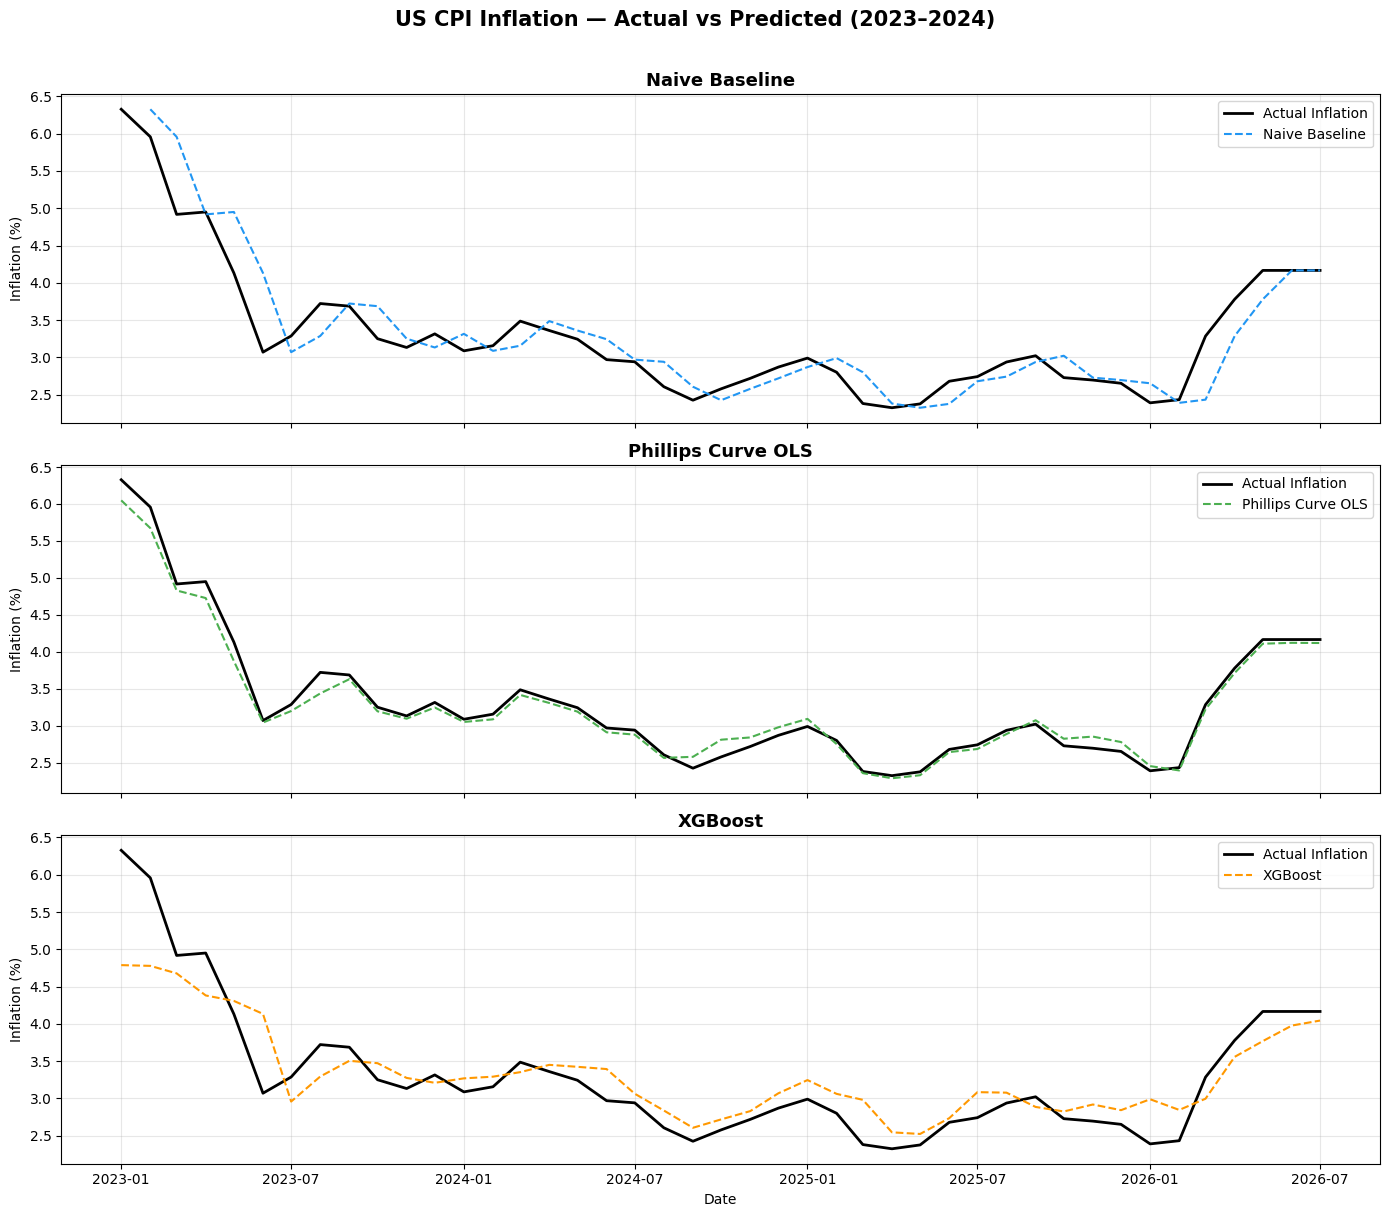

Plot saved to data folder.


In [15]:
import matplotlib.pyplot as plt

# Align all predictions to test index
results = {
    'Naive Baseline': naive_pred,
    'Phillips Curve OLS': ols_pred,
    'XGBoost': pd.Series(xgb_pred, index=y_test.index)
}

# Plot
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

colors = ['#2196F3', '#4CAF50', '#FF9800']
models = list(results.keys())

for i, (model_name, pred) in enumerate(results.items()):
    axes[i].plot(y_test.index, y_test.values, 
                 label='Actual Inflation', color='black', linewidth=2)
    axes[i].plot(pred.index, pred.values, 
                 label=f'{model_name}', color=colors[i], 
                 linewidth=1.5, linestyle='--')
    axes[i].set_title(f'{model_name}', fontsize=13, fontweight='bold')
    axes[i].set_ylabel('Inflation (%)')
    axes[i].legend(loc='upper right')
    axes[i].grid(True, alpha=0.3)

axes[-1].set_xlabel('Date')
fig.suptitle('US CPI Inflation — Actual vs Predicted (2023–2024)', 
             fontsize=15, fontweight='bold', y=1.01)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot saved to data folder.")

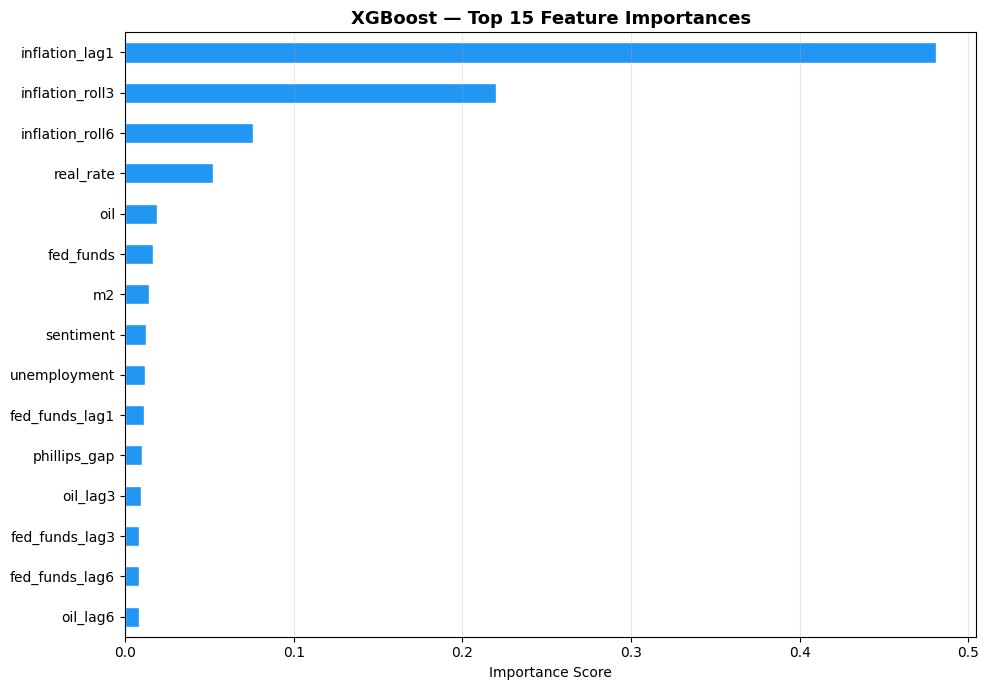

Feature importance saved to data folder.


In [18]:
import pandas as pd

# Feature importance
importance = pd.Series(
    xgb_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(10, 7))
importance.plot(kind='barh', ax=ax, color='#2196F3', edgecolor='white')
ax.set_title('XGBoost — Top 15 Feature Importances', 
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("Feature importance saved to data folder.")

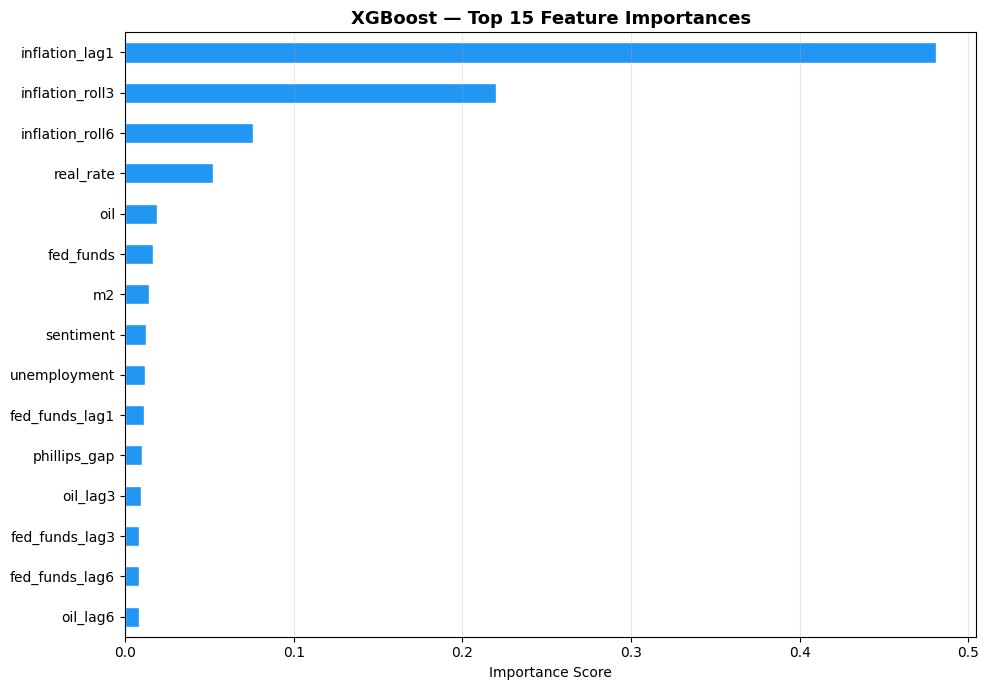

Feature importance saved.


In [19]:
import pandas as pd

# Feature importance
importance = pd.Series(
    xgb_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(10, 7))
importance.plot(kind='barh', ax=ax, color='#2196F3', edgecolor='white')
ax.set_title('XGBoost — Top 15 Feature Importances', 
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("Feature importance saved.")